In [53]:
#Escoger un conjuto de datos de mi interes

import pandas as pd
from google.colab import files
uploaded = files.upload ()

Saving netflix_titles.csv.zip to netflix_titles.csv (2).zip


In [ ]:
print ( "CONJUNTO DE DATOS ACERCA DE PELICULAS Y SERIES DE TELEVISION DISPONIBLES EN NETFLIX")
df = pd.read_csv('/content/netflix_titles.csv')

df.head()

In [54]:
print ( "EXPLORACION DE DATOS")
print ("VISUALIZACION DE LAS INFORMACION")
df.head()

EXPLORACION DE DATOS
VISUALIZACION DE LAS INFORMACION


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [55]:
print (("CANTIDAD DE FILAS:") , df.shape[0])
print (("CANTIDAD DE COLUMNAS:") , df.shape[1])
print (("INFORMACION GENERAL") , df.info())
print(("EXPLORACION DE DATOS NULOS"), df.isnull())
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

porcentaje_nulos

CANTIDAD DE FILAS: 8807
CANTIDAD DE COLUMNAS: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 894.6+ KB
INFORMACIO

,0
show_id,0.00
type,0.00
title,0.00
director,0.00
cast,0.00
country,0.00
date_added,1.11
release_year,0.00
rating,0.00
duration,0.03


In [ ]:
print ("EXPLORACION DE DATOS NULOS")
df.isnull().sum()

porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

porcentaje_nulos



EXPLORACION DE DATOS NULOS


,0
show_id,0.00
type,0.00
title,0.00
director,29.91
cast,9.37
country,9.44
date_added,0.11
release_year,0.00
rating,0.05
duration,0.03


In [56]:

df[df['rating'].str.contains('min', na=False)][['title', 'rating', 'duration']]
df.loc[df['rating'].str.contains('min', na=False), 'rating'] = 'Unknown'

In [57]:
print ("EXPLORACION DE DATOS DUPLICADOS")
print("CANTIDAD DE DATOS DUPLICADOS:", df.duplicated().sum())

EXPLORACION DE DATOS DUPLICADOS
CANTIDAD DE DATOS DUPLICADOS: 0


In [ ]:
#REMPLAZAR VALORES NULOS
print("VALORES NULOS ")
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df.isnull().sum()

VALORES NULOS 


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


In [58]:
print ("TRANSFORMACION DE COLUMNAS Y CREACION DE VARIABLES")

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df[['title', 'date_added', 'year_added']].head()

TRANSFORMACION DE COLUMNAS Y CREACION DE VARIABLES


,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021.0
1,Blood & Water,2021-09-24,2021.0
2,Ganglands,2021-09-24,2021.0
3,Jailbirds New Orleans,2021-09-24,2021.0
4,Kota Factory,2021-09-24,2021.0


In [59]:
print ("AGRUPACIONES CON GROUPBY")
print ("PELICULAS Y SERIES DISPONIBLES")
contenido_tipo = (
    df.groupby('type')
      .size()
      .reset_index(name='cantidad')
)

contenido_tipo


AGRUPACIONES CON GROUPBY
PELICULAS Y SERIES DISPONIBLES


,type,cantidad
0,Movie,6131
1,TV Show,2676


In [60]:
print ("CONTENIDO AGREGADO POR AÑO")
contenido_año = (
    df.groupby('year_added')
      .size()
      .reset_index(name='cantidad')
      .sort_values('year_added')
)

contenido_año

CONTENIDO AGREGADO POR AÑO


,year_added,cantidad
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,10
6,2014.0,23
7,2015.0,73
8,2016.0,418
9,2017.0,1164


In [61]:
print ("CONTENIDO AGREGADO POR CLASIFICACION")
contenido_rating = (
    df.groupby('rating')
      .size()
      .reset_index(name='cantidad')
      .sort_values('cantidad', ascending=False)
)

contenido_rating

CONTENIDO AGREGADO POR CLASIFICACION


,rating,cantidad
8,TV-MA,3207
6,TV-14,2160
9,TV-PG,863
5,R,799
4,PG-13,490
11,TV-Y7,334
10,TV-Y,307
3,PG,287
7,TV-G,220
2,NR,80


¿HAY MAS PELICULAS O SERIES DE TELEVISION EN NETFLIX?


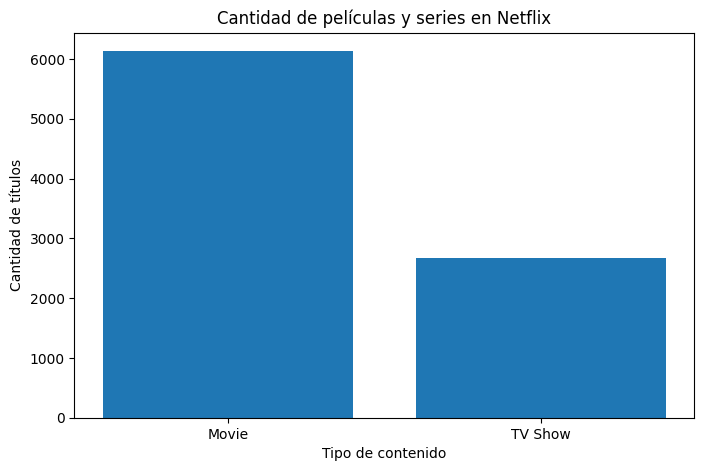

In [62]:
print ("¿HAY MAS PELICULAS O SERIES DE TELEVISION EN NETFLIX?")

contenido_tipo = df.groupby('type').size().reset_index(name='cantidad')

contenido_tipo
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(contenido_tipo['type'], contenido_tipo['cantidad'])

plt.title('Cantidad de películas y series en Netflix')
plt.xlabel('Tipo de contenido')
plt.ylabel('Cantidad de títulos')

plt.show()

**INTERPRETACION:** El catálogo analizado de Netflix tiene una mayor cantidad de películas que de series. Se identificaron 6.131 películas, mientras que las series de televisión representan 2.676 títulos. Esto significa que las películas constituyen aproximadamente el 70% del contenido analizado, mientras que las series representan cerca del 30%.

¿COMO HA VARIADO LA CANTIDAD DE CONTENIDO AGREGANDO A NETFLIX A TRAVES DE LOS AÑOS?


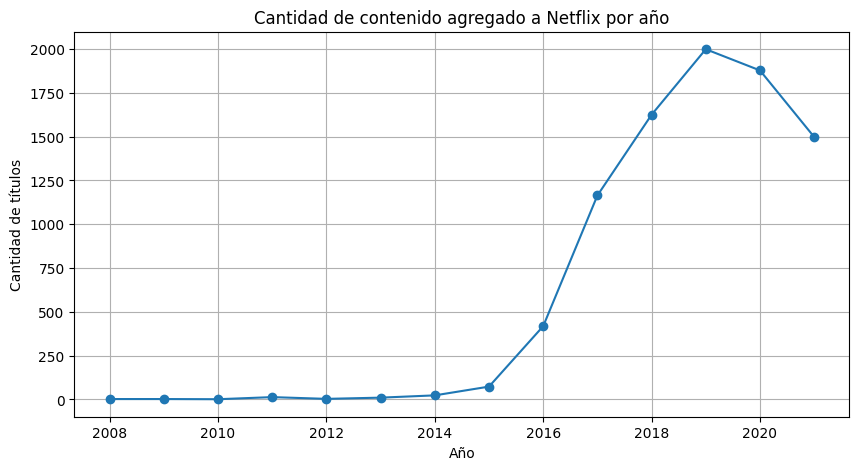

In [63]:
print ("¿COMO HA VARIADO LA CANTIDAD DE CONTENIDO AGREGANDO A NETFLIX A TRAVES DE LOS AÑOS?")
contenido_año = (
    df.groupby('year_added')
      .size()
      .reset_index(name='cantidad')
      .sort_values('year_added')
)

contenido_año

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    contenido_año['year_added'],
    contenido_año['cantidad'],
    marker='o'
)

plt.title('Cantidad de contenido agregado a Netflix por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de títulos')

plt.grid(True)
plt.show()

Interpretación: La cantidad de contenido agregado a Netflix aumentó durante los primeros años del período analizado y alcanzó su punto más alto en 2019, después se observa una disminución en los años siguientes. Esto indica que la incorporación de nuevos títulos no fue constante, sino que tuvo un período de crecimiento importante antes de reducirse.

CUALES SON LOS PAISES QUE TIENEN MAYOR CANTIDAD DE CONTENIDO EN NETFLIX?


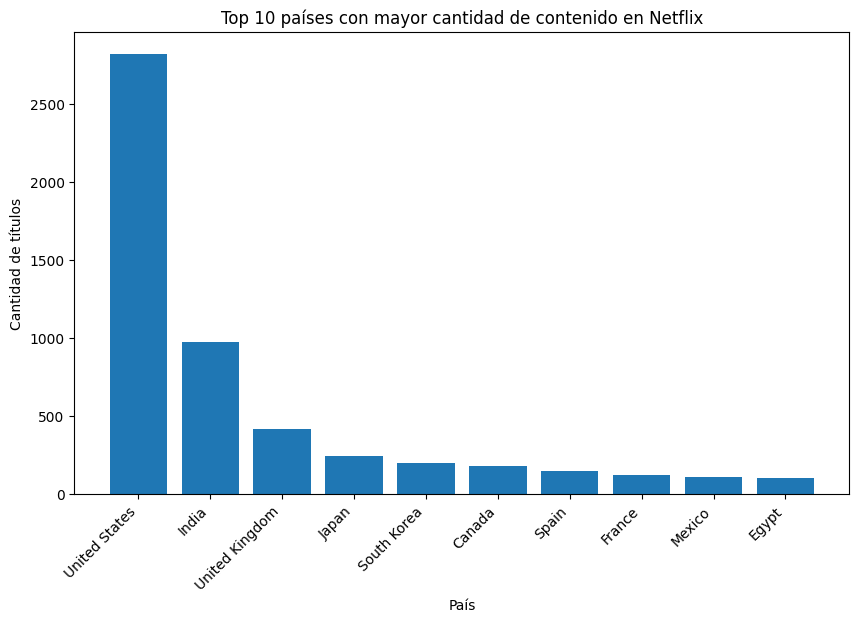

In [64]:
print ("CUALES SON LOS PAISES QUE TIENEN MAYOR CANTIDAD DE CONTENIDO EN NETFLIX?")
contenido_pais = (
    df.groupby('country')
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
)

# Excluir los registros sin país identificado
contenido_pais = contenido_pais[contenido_pais['country'] != 'Unknown']

top_10_paises = contenido_pais.head(10)
plt.figure(figsize=(10,6))

plt.bar(
    top_10_paises['country'],
    top_10_paises['cantidad']
)

plt.title('Top 10 países con mayor cantidad de contenido en Netflix')
plt.xlabel('País')
plt.ylabel('Cantidad de títulos')

plt.xticks(rotation=45, ha='right')

plt.show()

**Interpretación:** Estados Unidos es el país con mayor cantidad de contenido en el conjunto de datos de Netflix, seguido por India y Reino Unido. Los demás países del Top 10 presentan una cantidad considerablemente menor de títulos.

¿Cuales son los generos o categorias de contenido mas populares en Netflix?


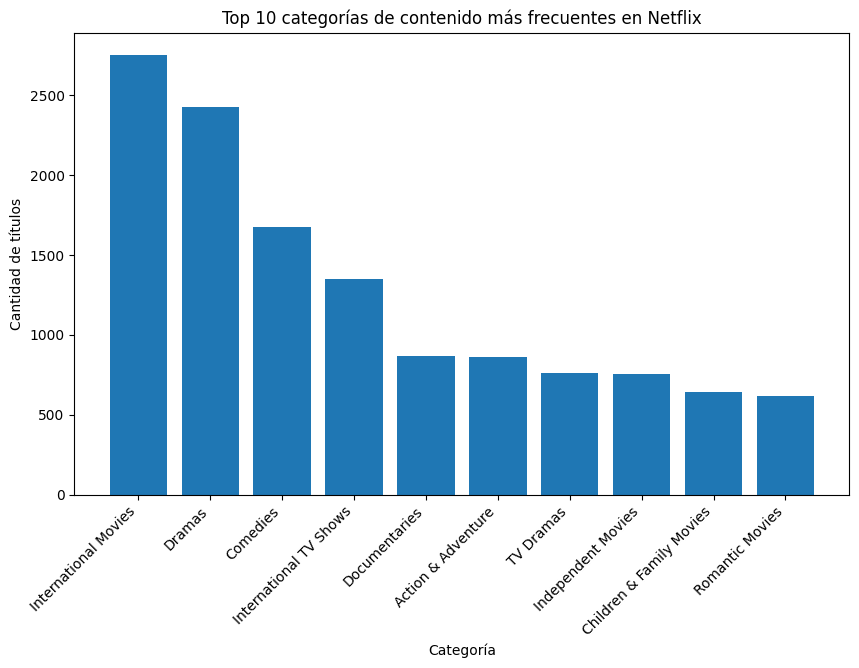

In [65]:
print ("¿Cuales son los generos o categorias de contenido mas populares en Netflix?")
df_generos = df.copy()
df_generos['listed_in'] = df_generos['listed_in'].str.split(', ')
df_generos = df_generos.explode('listed_in')
contenido_genero = (
    df_generos.groupby('listed_in')
    .size()
    .reset_index(name='cantidad')
    .sort_values('cantidad', ascending=False)
)

contenido_genero.head(10)
top_10_generos = contenido_genero.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_10_generos['listed_in'],
    top_10_generos['cantidad']
)

plt.title('Top 10 categorías de contenido más frecuentes en Netflix')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de títulos')

plt.xticks(rotation=45, ha='right')

plt.show()

**Interpretación: **Las categorías con mayor presencia en el catálogo analizado son International Movies y Dramas, seguidas por Comedies e International TV Shows. También tienen una presencia importante los documentales y las producciones de acción y aventura.

¿Cuales son las clasificaciones de edad mas comunes entre las peliculas y series de Netflix?


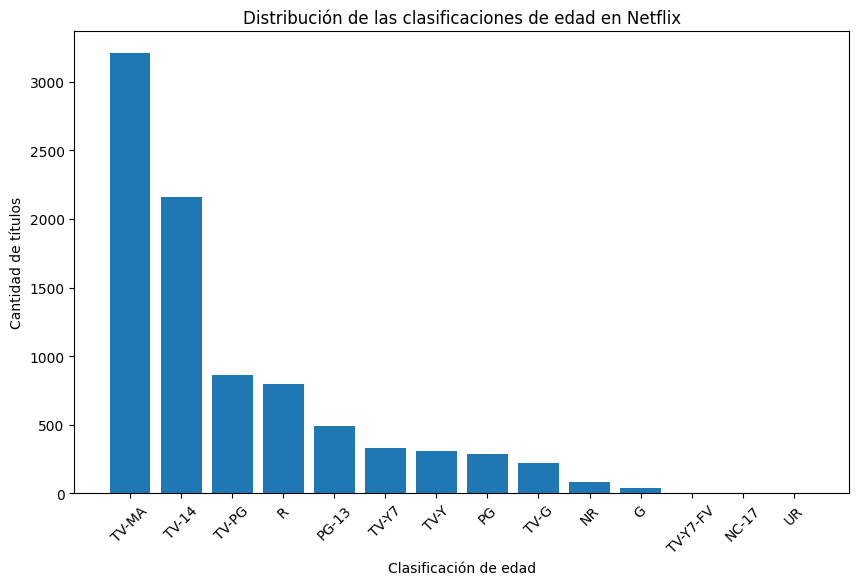

In [66]:
print ("¿Cuales son las clasificaciones de edad mas comunes entre las peliculas y series de Netflix?")
contenido_rating = (
    df.groupby('rating')
      .size()
      .reset_index(name='cantidad')
      .sort_values('cantidad', ascending=False)
)

contenido_rating
rating_conocido = contenido_rating[
    contenido_rating['rating'] != 'Unknown'
]

plt.figure(figsize=(10,6))

plt.bar(
    rating_conocido['rating'],
    rating_conocido['cantidad']
)

plt.title('Distribución de las clasificaciones de edad en Netflix')
plt.xlabel('Clasificación de edad')
plt.ylabel('Cantidad de títulos')

plt.xticks(rotation=45)

plt.show()

**Interpretación**: La clasificación más frecuente en el conjunto de datos es TV-MA, con más de 3.000 títulos. Le sigue TV-14, con más de 2.000 títulos. Después aparecen TV-PG y R, aunque con una cantidad considerablemente menor. Esto indica que una parte importante del catálogo analizado corresponde a contenidos dirigidos principalmente a adolescentes mayores y adultos

**CONCLUSIONES**

1. El catálogo analizado tiene una mayor presencia de películas que de series.
De los 8.807 títulos analizados, 6.131 son películas y 2.676 son series, por lo que las películas representan aproximadamente el 70% del conjunto de datos. Esto muestra que, dentro de la base analizada, la oferta de películas tiene un peso considerablemente mayor que la de series.

2. El contenido del catálogo presenta una fuerte diversidad geográfica y temática.
El análisis por países muestra que Estados Unidos aparece asociado con la mayor cantidad de títulos, seguido por India y Reino Unido. Al mismo tiempo, las categorías más frecuentes incluyen International Movies, Dramas y Comedies. Esto indica que el catálogo analizado combina contenido de diferentes países y géneros, en lugar de concentrarse en una sola categoría de entretenimiento.

3. Las clasificaciones de edad muestran una concentración en contenidos dirigidos a públicos adolescentes y adultos. La clasificación TV-MA es la más frecuente, seguida por TV-14, mientras que otras clasificaciones presentan cantidades menores. Este patrón indica que una parte importante del contenido analizado está clasificada para públicos de mayor edad, por lo que el catálogo no está compuesto principalmente por contenidos dirigidos a niños o a todas las edades.